# NB 03 — Exploratory Data Analysis

**Phase 2 — Task 2.3**

Produces:
- Word clouds (human vs AI)
- Top-20 unigram and bigram frequency charts
- Type-Token Ratio (TTR) vocabulary richness analysis
- Text / sentence length distributions
- Per-AI-model style comparison

In [1]:
# ── Session bootstrap ─────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
SRC_DIR = PROJECT_ROOT / 'src'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/__init__.py is committed to the repo, no runtime touch needed
print('PROJECT_ROOT:', PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection


In [ ]:
import subprocess, importlib
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import seaborn as sns
import pandas as pd
import numpy as np
from wordcloud import WordCloud
from pyspark.sql import functions as F

from src.utils import (
    create_spark_session, load_checkpoint, FIGURES_DIR, add_src_to_spark
)
from src.data_preparation import mapreduce_word_count, mapreduce_ngram_frequency

spark = create_spark_session('ArabicAIDetection_EDA')
add_src_to_spark(spark)

preprocessed_df = load_checkpoint(spark, 'preprocessed')
preprocessed_df.cache()
print(f'Loaded {preprocessed_df.count():,} rows')

PALETTE = {'Human': '#4A90D9', 'AI': '#E8603C'}


Loaded 41,940 rows


## 0. Arabic font setup

In [ ]:
# Install Arabic rendering support
!pip -q install arabic-reshaper python-bidi
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core fonts-noto-extra fonts-hosny-amiri

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-hosny-amiri.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-hosny-amiri_0.113-1_all.deb ...
Unpacking fonts-hosny-amiri (0.113-1) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-extra (20201225-1build1) ...
Setting up fonts-hosny-amiri (0.113-1) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import subprocess, arabic_reshaper
from bidi.algorithm import get_display

def get_font_path(name='Amiri'):
    try:
        return subprocess.check_output(['fc-match', '-f', '%{file}', name], text=True).strip()
    except Exception:
        return None

FONT_PATH = get_font_path('Amiri') or get_font_path('Noto Sans Arabic')
ARABIC_FONT = FontProperties(fname=FONT_PATH) if FONT_PATH else None
print('Arabic font:', FONT_PATH)

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

Arabic font: /usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-Regular.ttf


## 1. Word clouds — Human vs AI

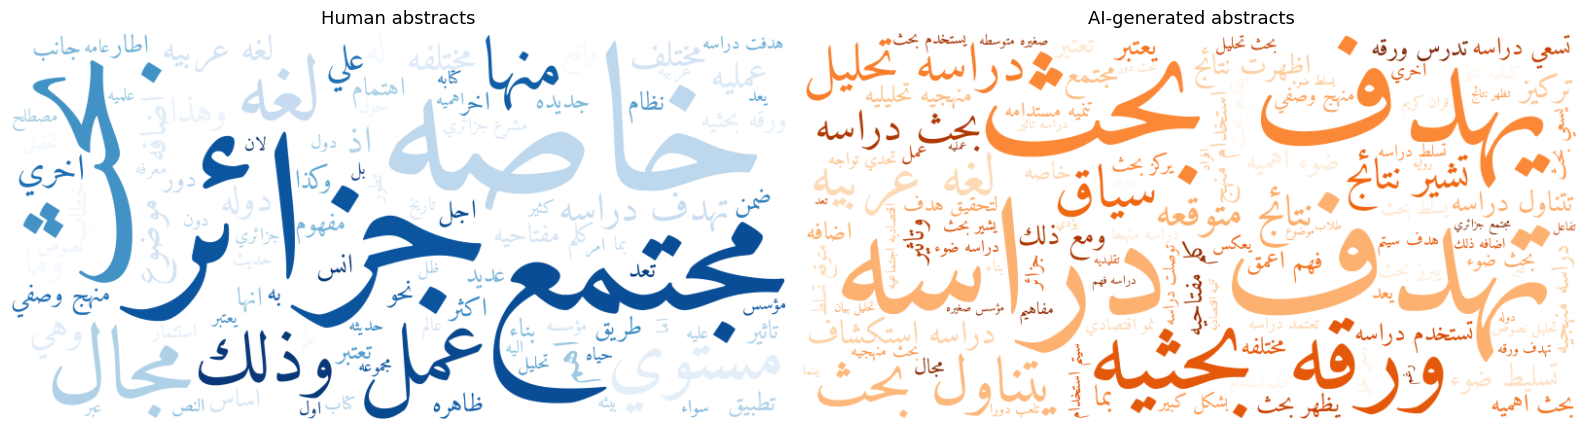

Saved: wordclouds.png


In [ ]:
def collect_text(df, label_val, frac=0.5):
    rows = (df.filter(F.col('label') == label_val)
              .select('clean_text')
              .sample(fraction=frac, seed=42)
              .collect())
    return ' '.join(r['clean_text'] for r in rows if r['clean_text'])

human_text = collect_text(preprocessed_df, 0)
ai_text    = collect_text(preprocessed_df, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, text, title, cmap in [
    (axes[0], human_text, 'Human abstracts', 'Blues'),
    (axes[1], ai_text,    'AI-generated abstracts', 'Oranges'),
]:
    wc = WordCloud(
        width=800, height=400, background_color='white',
        font_path=FONT_PATH, colormap=cmap, max_words=100,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'wordclouds.png'), dpi=150)
plt.show()
print('Saved: wordclouds.png')


## 2. Top-20 unigrams — Human vs AI

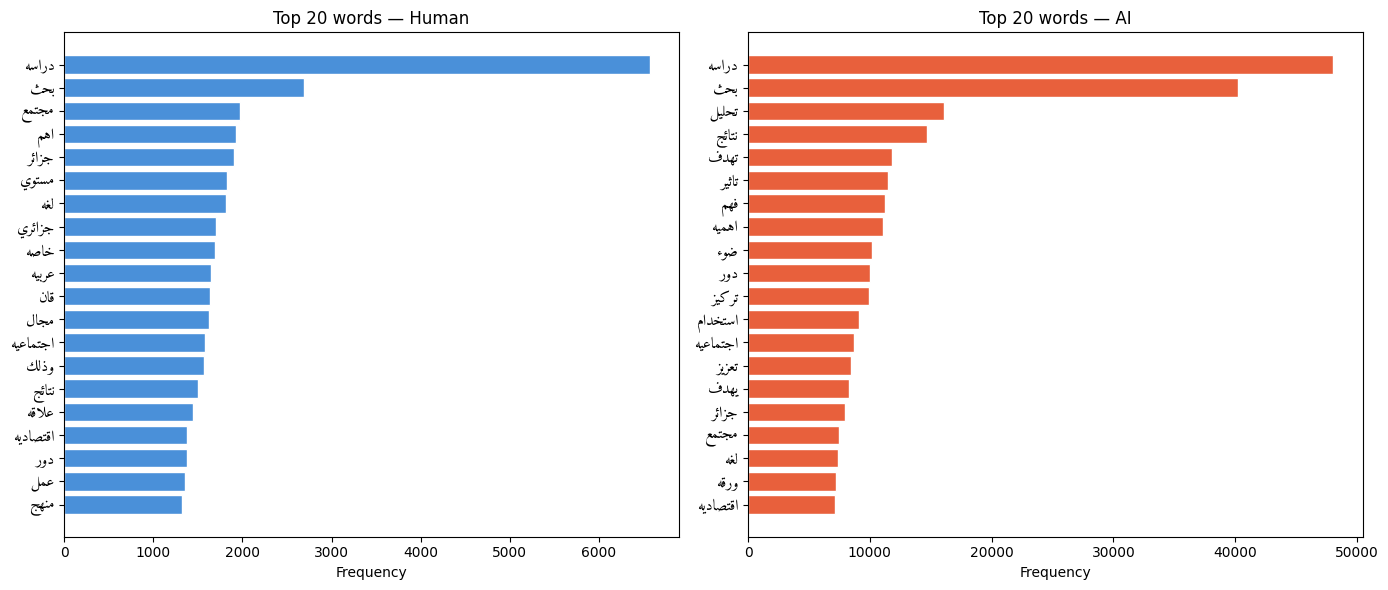

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label_val, label_name, color) in zip(axes, [
    (0, 'Human', PALETTE['Human']),
    (1, 'AI',    PALETTE['AI']),
]):
    sub = preprocessed_df.filter(F.col('label') == label_val)
    top = mapreduce_word_count(sub, 'clean_text').limit(20).toPandas().sort_values('count')
    top['word_display'] = top['word'].apply(fix_arabic)
    ax.barh(top['word_display'], top['count'], color=color, edgecolor='white')
    ax.set_title(f'Top 20 words — {label_name}', fontsize=12)
    ax.set_xlabel('Frequency')
    if ARABIC_FONT:
        for lbl in ax.get_yticklabels():
            lbl.set_fontproperties(ARABIC_FONT)
            lbl.set_fontsize(11)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'top_unigrams.png'), dpi=150, bbox_inches='tight')
plt.show()


## 3. Top-15 bigrams — Human vs AI

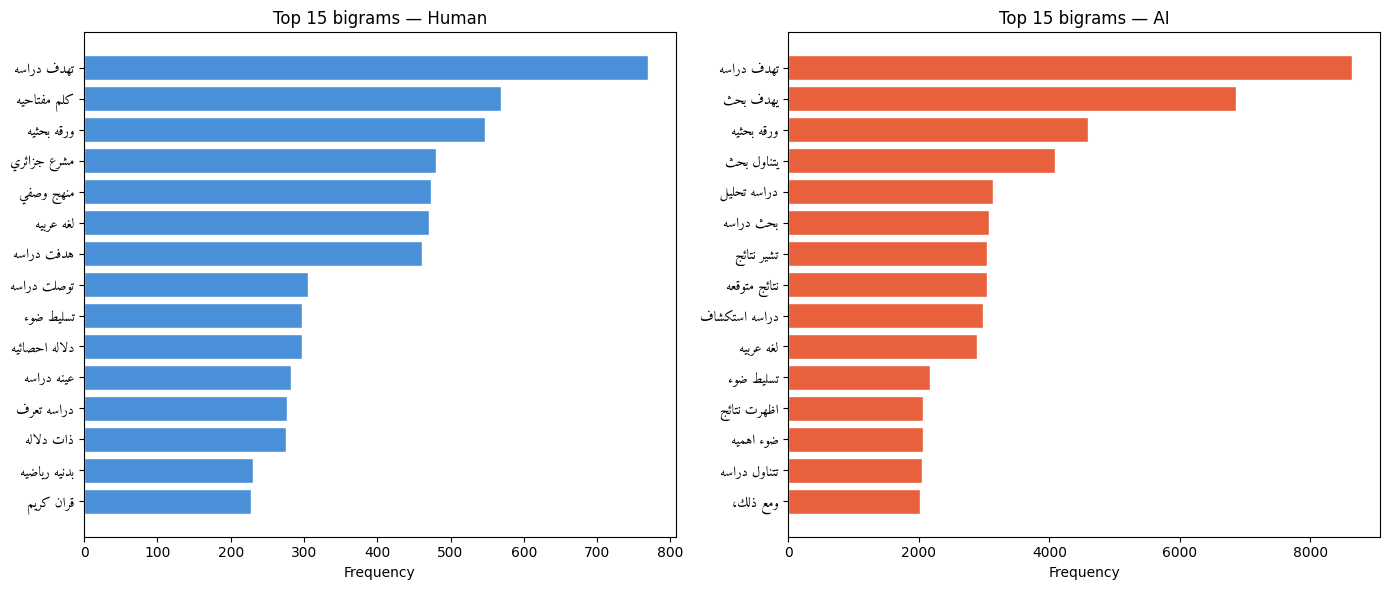

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label_val, label_name, color) in zip(axes, [
    (0, 'Human', PALETTE['Human']),
    (1, 'AI',    PALETTE['AI']),
]):
    sub = preprocessed_df.filter(F.col('label') == label_val)
    top = (mapreduce_ngram_frequency(sub, n=2, text_col='clean_text')
           .limit(15).toPandas().sort_values('count'))
    top['ngram_display'] = top['ngram'].apply(fix_arabic)
    ax.barh(top['ngram_display'], top['count'], color=color, edgecolor='white')
    ax.set_title(f'Top 15 bigrams — {label_name}', fontsize=12)
    ax.set_xlabel('Frequency')
    if ARABIC_FONT:
        for lbl in ax.get_yticklabels():
            lbl.set_fontproperties(ARABIC_FONT)
            lbl.set_fontsize(10)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'top_bigrams.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. Type-Token Ratio (TTR) — Vocabulary Richness

   label  mean_TTR  std_TTR  n_docs
0  Human    0.8419   0.0783    1000
1     AI    0.8245   0.0471    1000


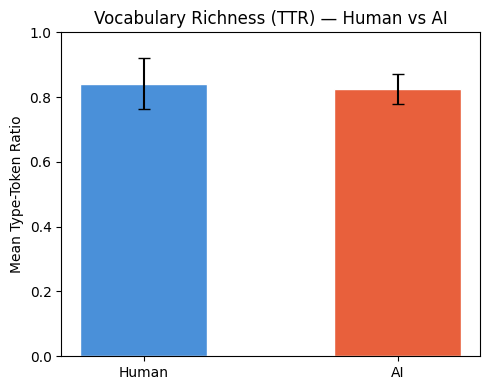

In [ ]:
results = []
for label_val, label_name in [(0, 'Human'), (1, 'AI')]:
    sample = (preprocessed_df.filter(F.col('label') == label_val)
              .select('clean_text').sample(fraction=0.3, seed=42).limit(1000).collect())
    ttrs = [
        len(set(r['clean_text'].split())) / len(r['clean_text'].split())
        for r in sample if len(r['clean_text'].split()) > 5
    ]
    results.append({'label': label_name, 'mean_TTR': round(np.mean(ttrs), 4),
                    'std_TTR': round(np.std(ttrs), 4), 'n_docs': len(ttrs)})

ttr_df = pd.DataFrame(results)
print(ttr_df)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(ttr_df['label'], ttr_df['mean_TTR'],
              color=[PALETTE['Human'], PALETTE['AI']], edgecolor='white', width=0.5)
ax.errorbar(ttr_df['label'], ttr_df['mean_TTR'], yerr=ttr_df['std_TTR'],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean Type-Token Ratio')
ax.set_title('Vocabulary Richness (TTR) — Human vs AI')
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'ttr_comparison.png'), dpi=150)
plt.show()


## 5. Text length distribution

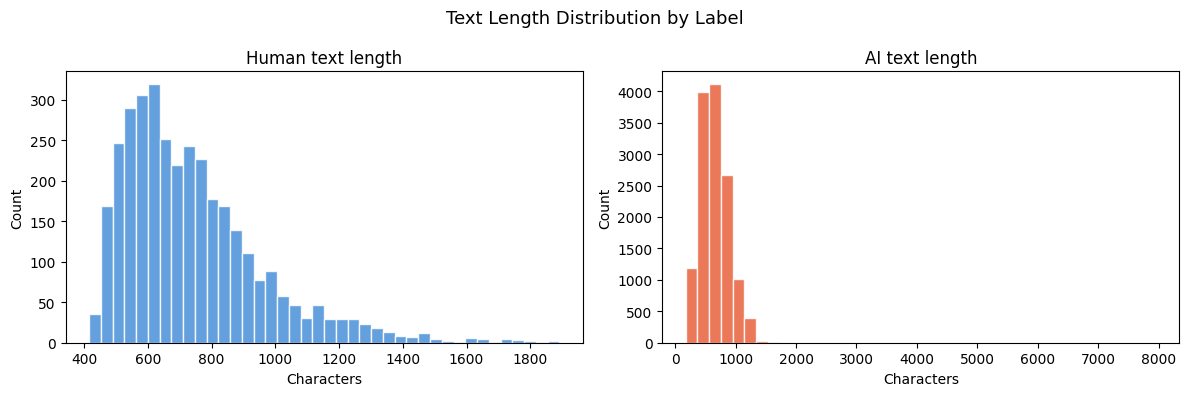

In [ ]:
plot_df = (
    preprocessed_df
    .withColumn('text_len', F.length('text'))
    .select('text_len', 'label')
    .sample(fraction=0.4, seed=42)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lbl, grp) in zip(axes, plot_df.groupby('label')):
    ax.hist(grp['text_len'], bins=40, edgecolor='white', alpha=0.85,
            color=PALETTE['Human'] if lbl == 0 else PALETTE['AI'])
    ax.set_title(f'{"Human" if lbl==0 else "AI"} text length')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')

plt.suptitle('Text Length Distribution by Label', fontsize=13)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'text_length_distribution.png'), dpi=150)
plt.show()


## 6. Per-AI-model style comparison

  source_model   avg_words   avg_chars  n_docs
0        allam   72.382690  421.119933    8388
1        human   91.636743  524.802575    8388
2         jais   59.259180  343.958870    8388
3        llama   79.167144  457.196352    8388
4       openai  107.787077  632.188841    8388


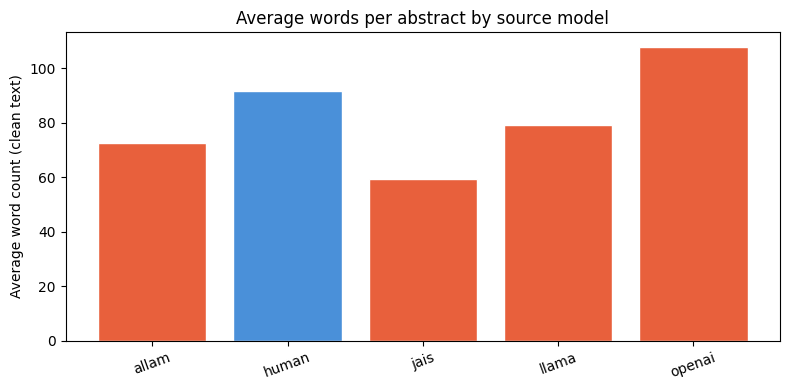

In [ ]:
model_stats = (
    preprocessed_df
    .withColumn('word_count', F.size(F.split('clean_text', r'\s+')))
    .groupBy('source_model')
    .agg(
        F.avg('word_count').alias('avg_words'),
        F.avg(F.length('clean_text')).alias('avg_chars'),
        F.count('*').alias('n_docs'),
    )
    .orderBy('source_model')
    .toPandas()
)
print(model_stats)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4A90D9' if m == 'human' else '#E8603C' for m in model_stats['source_model']]
ax.bar(model_stats['source_model'], model_stats['avg_words'], color=colors, edgecolor='white')
ax.set_ylabel('Average word count (clean text)')
ax.set_title('Average words per abstract by source model')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'words_per_model.png'), dpi=150)
plt.show()
